<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/prueba_de_promedios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#<span style="color:brown;">**PRUEBA DE PROMEDIO**</span>
<span style="color:blue;"></span>


La prueba de promedios es una prueba estadística utilizada en simulación para verificar
si un conjunto de números pseudoaleatorios sigue un comportamiento consistente con la
distribución uniforme en el intervalo $(0,1)$.

Sea $\{U_1, U_2, \dots, U_n\}$ una muestra de números aleatorios independientes con
distribución uniforme $U(0,1)$.



**Hipótesis**

Se plantean las siguientes hipótesis:


$$ H_0 : \mu = \frac{1}{2}$$



$$ H_1 : \mu \neq \frac{1}{2}$$


donde $\mu$ es la media poblacional.

**Estadístico de prueba**

La media muestral se calcula como:

$$\bar{U} = \frac{1}{n} \sum_{i=1}^{n} U_i $$


La varianza de una distribución uniforme $U(0,1)$ es:


$$\sigma^2 = \frac{1}{12}$$


Por el Teorema del Límite Central, para $n$ suficientemente grande,
el estadístico


$$Z = \frac{\bar{U} - \frac{1}{2}}{\sqrt{\frac{1}{12n}}}$$


se distribuye aproximadamente como una normal estándar:


$$Z \sim N(0,1)$$


**Regla de decisión**

Para un nivel de significancia $\alpha$:



*   Se rechaza $H_0$ si $|Z| > Z_{\alpha/2}$
*   En caso contrario, no se rechaza $H_0$


**Interpretación**

Si no se rechaza $H_0$, se concluye que no existe evidencia suficiente para afirmar
que los números generados tienen una media diferente de $\frac{1}{2}$, lo cual es
consistente con una distribución uniforme en $(0,1)$.


In [26]:
import numpy as np # Importa la librería NumPy para realizar cálculos numéricos.
from scipy.stats import norm # Importa la función 'norm' de SciPy para cálculos relacionados con la distribución normal.
import scipy.stats as st # Importa la librería SciPy.stats con el alias 'st' para funciones estadísticas.

In [27]:
numeros = [
    [0.78961, 0.05230, 0.10689, 0.55877, 0.14151],
    [0.76086, 0.12079, 0.27738, 0.65726, 0.79269],
    [0.80548, 0.82654, 0.29453, 0.20852, 0.42989],
    [0.58518, 0.98611, 0.34488, 0.34358, 0.11537],
    [0.89898, 0.57880, 0.67621, 0.05010, 0.00121],
    [0.28269, 0.73059, 0.70119, 0.18284, 0.49962],
    [0.38618, 0.76910, 0.68834, 0.55170, 0.10850],
    [0.79982, 0.45679, 0.21631, 0.87616, 0.55743],
    [0.58962, 0.33216, 0.03185, 0.61168, 0.09264],
    [0.69823, 0.17028, 0.05475, 0.91512, 0.76262],
    [0.29931, 0.30861, 0.83358, 0.51781, 0.03272],
    [0.57410, 0.26593, 0.85903, 0.48338, 0.35288],
    [0.24000, 0.65559, 0.38507, 0.90829, 0.94187],
    [0.93655, 0.88809, 0.81772, 0.36982, 0.19904],
    [0.54325, 0.62400, 0.09133, 0.41678, 0.33954],
    [0.58244, 0.85853, 0.88752, 0.38729, 0.15506],
    [0.23949, 0.53559, 0.33881, 0.49883, 0.75103],
    [0.19962, 0.65002, 0.74579, 0.79113, 0.63453],
    [0.19147, 0.40644, 0.08128, 0.73435, 0.22724],
    [0.22287, 0.07281, 0.64183, 0.44267, 0.72102]
]


Aplicamos la prueba de estadisticos

In [28]:
# Aplanar la lista de listas en una sola lista
datos_de_numeros = [item for sublista in numeros for item in sublista]

Obtener el número de muestras y la media muestral

In [29]:
N = len(datos_de_numeros)
x_bar = np.mean(datos_de_numeros)

Es la media de la muestra

In [30]:
x_bar

np.float64(0.483516)

 Calcular el estadístico $Z_0$ utilizando la fórmula proporcionada
 $Z_0=\frac{\bar{x}-\frac{1}{2}\sqrt{N}}{\sqrt{\frac{1}{12}}}$

In [31]:
# La fórmula correcta para el estadístico Z para la media de U(0,1) es:
# Z = (x_bar - 0.5) * np.sqrt(N) / np.sqrt(1/12)
Z0 = (x_bar - 0.5) * np.sqrt(N) / np.sqrt(1/12)

In [32]:
Z0

np.float64(-0.5710225102393075)

Definir el nivel de significancia (alpha)

In [33]:
alpha = 0.05 # Nivel de significancia comúnmente utilizado

 Calcular el valor crítico de Z para una prueba de dos colas

In [34]:
z_critico = norm.ppf(1 - alpha/2)

resultados_prueba = []
resultados_prueba.append(f"Número de muestras (N): {N}")
resultados_prueba.append(f"Media muestral (x̄): {x_bar:.4f}")
resultados_prueba.append(f"Estadístico Z calculado (Z0): {Z0:.4f}")
resultados_prueba.append(f"Nivel de significancia (α): {alpha}")
resultados_prueba.append(f"Valor Z crítico (Z_α/2): {z_critico:.4f}")

 Realizar la prueba de hipótesis

 * HIPOTESIS NULA:
$$H_o: μ=0.5 = \frac{1}{2}$$
* HIPOTESIS ALTERNATIVA:
$$ H_A:μ \neq 0.5 = \frac{1}{2}$$

In [35]:
if abs(Z0) < z_critico:
    resultados_prueba.append(f"\nDado que |Z_0| ({abs(Z0):.4f}) < Z_crítico ({z_critico:.4f}), NO RECHAZAMOS la hipótesis nula.")
    resultados_prueba.append("Esto sugiere que la media de los números generados no es significativamente diferente de 0.5.")
else:
    resultados_prueba.append(f"\nDado que |Z_0| ({abs(Z0):.4f}) >= Z_crítico ({z_critico:.4f}), RECHAZAMOS la hipótesis nula.")
    resultados_prueba.append("Esto sugiere que la media de los números generados es significativamente diferente de 0.5.")


In [36]:
# Imprimir los resultados
print('\n'.join(resultados_prueba))

Número de muestras (N): 100
Media muestral (x̄): 0.4835
Estadístico Z calculado (Z0): -0.5710
Nivel de significancia (α): 0.05
Valor Z crítico (Z_α/2): 1.9600

Dado que |Z_0| (0.5710) < Z_crítico (1.9600), NO RECHAZAMOS la hipótesis nula.
Esto sugiere que la media de los números generados no es significativamente diferente de 0.5.


A continuacion se procedera a calcular el promedio

In [37]:


def promedio(numeros, alfa):

  x= np.mean(numeros)
  N=len(numeros)

  z=(x-0.5)*np.sqrt(N)/np.sqrt(1/12)

  z_c = st.norm.ppf(1-alfa/2)

  if abs(z)<z_c:
    print("No se rechaza H_0: La muestra proviene de una dsitribución U(0,1)" )
  else:
    print("SE rechaza H_0: La muestra proviene de una dsitribución U(0,1)")
promedio(datos_de_numeros, 0.05)
print(np.mean(datos_de_numeros))

No se rechaza H_0: La muestra proviene de una dsitribución U(0,1)
0.483516


 Se calcula la media muestral $\bar{x}$ y el tamaño $N$.

 Bajo $H_0: X \sim U(0,1)$, se tiene $\mathbb{E}(X)=0.5$ y $\mathrm{Var}(X)=\frac{1}{2}$.

Se construye el estadístico

 que bajo $H_0$ sigue aproximadamente una $N(0,1)$.
 $$Z = \frac{(\bar{x}-0.5)\sqrt{N}}{\sqrt{\frac{1}{12}}}$$,
 Se compara |Z| con el valor crítico $z_{1-\frac{\alpha}{2}}$;
 si $|Z|<z_{1-\frac{\alpha}{2}}$no se rechaza $H_0$, en otro caso se rechaza.
 Finalmente se imprime la media muestral.

In [38]:
import matplotlib.pyplot as plt # Importa la librería Matplotlib para crear gráficos.

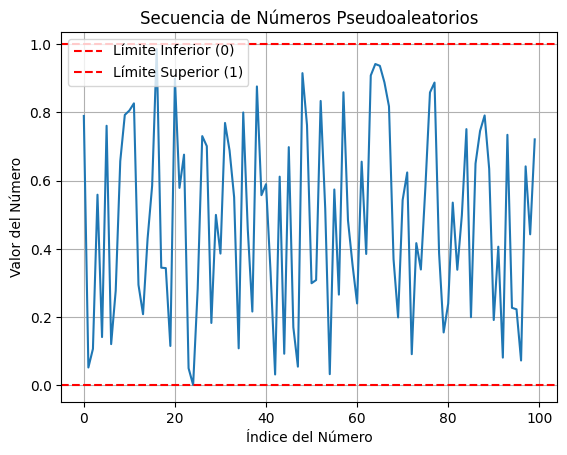

In [39]:
plt.figure()
plt.plot(datos_de_numeros)
plt.title('Secuencia de Números Pseudoaleatorios')
plt.xlabel('Índice del Número')
plt.ylabel('Valor del Número')
plt.axhline(0, color='red', linestyle='--', label='Límite Inferior (0)')
plt.axhline(1, color='red', linestyle='--', label='Límite Superior (1)')
plt.legend()
plt.grid(True)
plt.show()

La gráfica muestra la secuencia de números pseudoaleatorios generados
a lo largo del tiempo. En el eje horizontal se representa el índice
(o posición) de cada número dentro de la muestra, mientras que en el
eje vertical se observa el valor que toma cada uno.

Las líneas rojas punteadas en $y=0$ y $y=1$ indican los límites teóricos
del intervalo $(0,1)$, dentro del cual deberían encontrarse todos los
números si provienen de una distribución uniforme.

Visualmente, esta gráfica permite apreciar el comportamiento de la
secuencia: si los puntos se distribuyen sin un patrón evidente y se
mantienen dentro del intervalo esperado, se tiene una primera impresión
de que el generador produce valores adecuados.





#<span style="color:brown;">**Conclusión***</span>
<span style="color:blue;"></span>

Como podemos observar, este programa no solo realiza cálculos numéricos, sino que intenta responder
una pregunta fundamental en simulación: ¿los números que estamos utilizando
realmente se comportan como números aleatorios uniformes?

A través de la Prueba de Promedios, se analiza si la media de los 100 valores
generados es coherente con la media teórica de una distribución $U(0,1)$,
que es $0.5$. El estadístico $Z_0$ nos permite medir qué tan lejos está la
media observada de ese valor esperado.

El resultado muestra que la diferencia encontrada no es estadísticamente
significativa al nivel de $\alpha = 0.05$. En términos sencillos, no tenemos
evidencia suficiente para decir que estos números “se están comportando mal”.
Su promedio es consistente con lo que esperaríamos de una distribución uniforme.

Por otro lado, la gráfica complementa el análisis estadístico. Visualmente
podemos observar que los valores fluctúan dentro del intervalo $(0,1)$ sin
mostrar patrones evidentes o tendencias claras. Esto genera una confianza
adicional en el comportamiento del conjunto de datos.

En conjunto, el programa combina teoría estadística, implementación
computacional y visualización gráfica para ofrecer una evaluación integral.
Más allá de los números y fórmulas, el mensaje es claro: los datos analizados
pasan la prueba de promedio y, desde esta perspectiva, pueden considerarse
adecuados para fines de simulación.
